
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.85      0.91       209
           1       0.73      0.96      0.83        91

    accuracy                           0.88       300
   macro avg       0.85      0.90      0.87       300
weighted avg       0.90      0.88      0.88       300



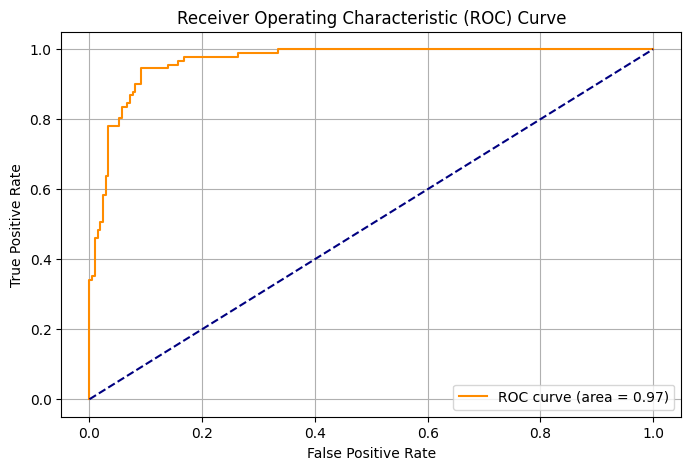


Model Coefficients (sorted by importance):
  Feature  Coefficient
5      X5    -1.931916
9      X9     1.439469
4      X4     0.767930
1      X1     0.383118
2      X2    -0.234578
3      X3     0.109555
6      X6    -0.029763
7      X7    -0.010524
0      X0     0.000000
8      X8     0.000000
Classification Report (KAN):
              precision    recall  f1-score   support

           0       0.98      0.85      0.91       209
           1       0.73      0.96      0.83        91

    accuracy                           0.88       300
   macro avg       0.85      0.90      0.87       300
weighted avg       0.90      0.88      0.88       300



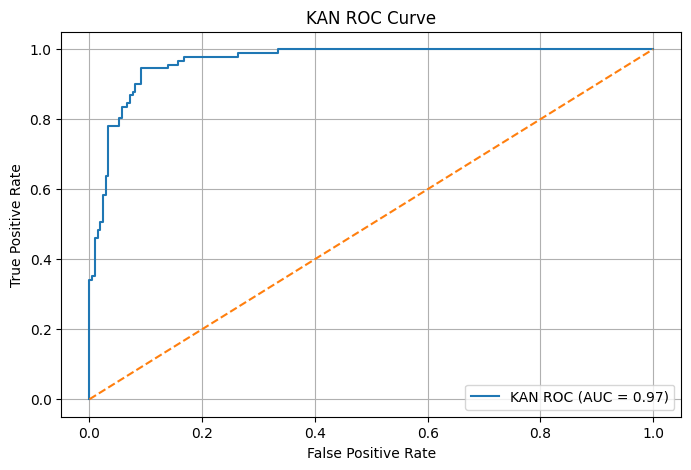


Model Coefficients (identical to sklearn LR):
  Feature  Coefficient
5      X5    -1.931916
9      X9     1.439469
4      X4     0.767930
1      X1     0.383118
2      X2    -0.234578
3      X3     0.109555
6      X6    -0.029763
7      X7    -0.010524
0      X0     0.000000
8      X8     0.000000


In [1]:
# Example of using KAN to approximate LR and further fine-tuning it
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve, auc

# 1. Simulate a credit scoring-like dataset
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    n_classes=2,
    weights=[0.7, 0.3],  # Imbalance: 70% "good" payers, 30% "bad"
    class_sep=1.5,
    random_state=42
)

# 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Feature scaling (important for logistic regression when regularizing)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Setup logistic regression with important hyperparameters
model = LogisticRegression(
    penalty='l1',             # Ridge regularization (common for logistic regression)
    C=0.3,                    # Strength of regularization (smaller = stronger regularization)
    solver='liblinear',       # Good default solver for small-to-medium datasets
    class_weight='balanced',  # Adjust for class imbalance
    max_iter=500,             # Allow more iterations to ensure convergence
    random_state=42
)

# 5. Train the model
model.fit(X_train_scaled, y_train)

# 6. Evaluate the model
y_pred = model.predict(X_test_scaled)
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 7. Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# 8. Print model coefficients
coefficients = pd.DataFrame({
    'Feature': [f'X{i}' for i in range(X.shape[1])],
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("\nModel Coefficients (sorted by importance):")
print(coefficients)

coefs     = model.coef_[0]       # shape (10,)
intercept = model.intercept_[0]  # scalar

# 4. Build an equivalent KAN via the symbolic compiler
from kan.compiler import kanpiler     # compiler API
import sympy as sp

# 4a. Create Sympy symbols x0…x9
x_symbols = sp.symbols('x0:10')

# 4b. Build the exact logistic-expression
linear_combo = sum(coefs[i] * x_symbols[i] for i in range(10)) + intercept
logistic_expr = 1 / (1 + sp.exp(-linear_combo))
logistic_expr

# 4c. Compile into a KAN (grid & k chosen to exactly represent sigmoid)
#     grid >= 1 is fine since it's symbolic.
kan_model = kanpiler(x_symbols, logistic_expr, grid=5, k=3, auto_save=False)

# 5. Evaluate on test set
kan_model.eval()
import torch
X_t = torch.from_numpy(X_test_scaled.astype(np.float32))
with torch.no_grad():
    y_prob_kan = kan_model(X_t).numpy().ravel()
    y_pred_kan = (y_prob_kan > 0.5).astype(int)

# 6. Metrics — should match sklearn exactly
print("Classification Report (KAN):")
print(classification_report(y_test, y_pred_kan))

# 7. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_kan)
roc_auc     = auc(fpr, tpr)

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, label=f'KAN ROC (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('KAN ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# 8. Display coefficients for sanity
coeff_df = pd.DataFrame({
    'Feature':     [f'X{i}' for i in range(10)],
    'Coefficient': coefs
}).sort_values(by='Coefficient', key=abs, ascending=False)
print("\nModel Coefficients (identical to sklearn LR):")
print(coeff_df)

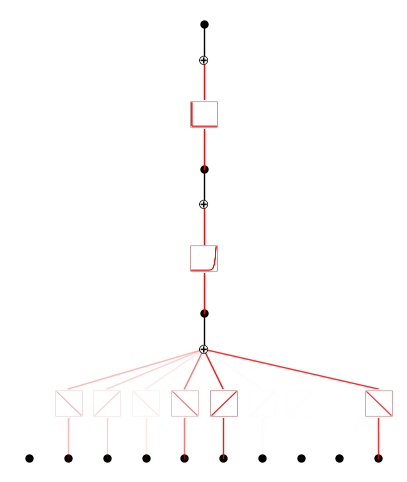

In [2]:
kan_model.plot()

Epoch 1, Loss: 0.6467
Epoch 2, Loss: 0.6305
Epoch 3, Loss: 0.6153
Epoch 4, Loss: 0.6007
Epoch 5, Loss: 0.5857
Epoch 6, Loss: 0.5721
Epoch 7, Loss: 0.5606
Epoch 8, Loss: 0.5520
Epoch 9, Loss: 0.5444
Epoch 10, Loss: 0.5386
Epoch 11, Loss: 0.5315
Epoch 12, Loss: 0.5258
Epoch 13, Loss: 0.5195
Epoch 14, Loss: 0.5145
Epoch 15, Loss: 0.5084
Epoch 16, Loss: 0.5029
Epoch 17, Loss: 0.4979
Epoch 18, Loss: 0.4925
Epoch 19, Loss: 0.4880
Epoch 20, Loss: 0.4828
Epoch 21, Loss: 0.4781
Epoch 22, Loss: 0.4733
Epoch 23, Loss: 0.4692
Epoch 24, Loss: 0.4652
Epoch 25, Loss: 0.4600
Epoch 26, Loss: 0.4569
Epoch 27, Loss: 0.4519
Epoch 28, Loss: 0.4481
Epoch 29, Loss: 0.4439
Epoch 30, Loss: 0.4402
Epoch 31, Loss: 0.4366
Epoch 32, Loss: 0.4329
Epoch 33, Loss: 0.4297
Epoch 34, Loss: 0.4257
Epoch 35, Loss: 0.4223
Epoch 36, Loss: 0.4192
Epoch 37, Loss: 0.4156
Epoch 38, Loss: 0.4124
Epoch 39, Loss: 0.4094
Epoch 40, Loss: 0.4063
Epoch 41, Loss: 0.4034
Epoch 42, Loss: 0.4004
Epoch 43, Loss: 0.3977
Epoch 44, Loss: 0.39

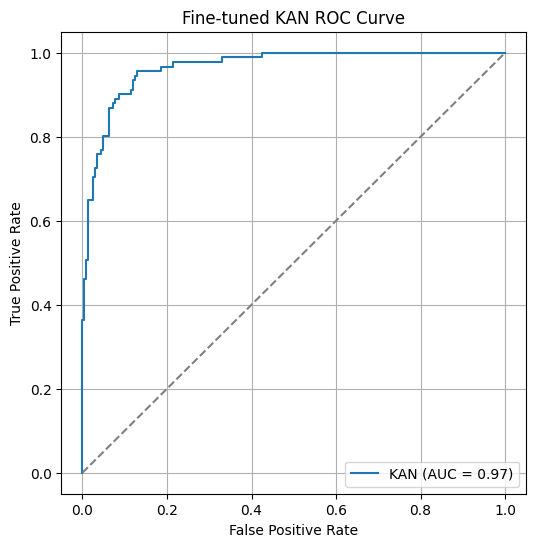

In [3]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F
from sklearn.metrics import classification_report, roc_curve, auc
import matplotlib.pyplot as plt

# Assume X_train_scaled, y_train, X_test_scaled, y_test, and kan_model already exist

# 0. Put model in train mode
kan_model.train()

# 1. If you want to keep the final edge pinned to sigmoid,
#    freeze its spline parameters so outputs stay valid probabilities.
#    Otherwise comment these two lines out to fine‐tune it too.
for name, p in kan_model.named_parameters():
    if 'layer1' in name or 'splines.1' in name:  
        p.requires_grad = False
    

# Prepare dataset
X_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_t = torch.tensor(y_train,       dtype=torch.float32).unsqueeze(1)
loader = DataLoader(TensorDataset(X_t, y_t), batch_size=32, shuffle=True)

# Use BCE on probabilities
criterion = F.binary_cross_entropy
criterion = torch.nn.functional.binary_cross_entropy_with_logits

# Fine-tune
kan_model.train()
optimizer = torch.optim.Adam(kan_model.parameters(), lr=1e-3)

for epoch in range(50):
    total_loss = 0
    for xb, yb in loader:
        probs = kan_model(xb)               # ∈ (0,1)
        loss  = criterion(probs, yb)        # correct: input=probs
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader.dataset):.4f}")


# 5. Switch to eval and predict on test set
kan_model.eval()
with torch.no_grad():
    X_te = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_prob = torch.sigmoid(kan_model(X_te)).numpy().ravel()
    y_pred = (y_prob > 0.5).astype(int)

# 6. Classification report
print("\nFine-tuned KAN Classification Report:")
print(classification_report(y_test, y_pred))

# 7. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc     = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'KAN (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Fine-tuned KAN ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [4]:
import torch
import torch.nn as nn
from torch.distributions import Bernoulli
from sklearn.metrics import roc_curve

# —— Utility: KS score on binary actions —— 
def ks_score(y_true, y_actions):
    fpr, tpr, _ = roc_curve(y_true.cpu().numpy(), y_actions.cpu().numpy())
    return float((tpr - fpr).max())

In [ ]:
import torch
from torch.distributions import Bernoulli
from sklearn.metrics import roc_curve

# ---- KS score ----
def ks_score(y_true, y_pred):
    fpr, tpr, _ = roc_curve(y_true.cpu().numpy(), y_pred.cpu().numpy())
    return float((tpr - fpr).max())

# ---- REINFORCE with training on train set and reward from OOT ----
def train_kan_reinforce(kan_model, X_train, y_train, X_oot, y_oot,
                        lr=1e-4, episodes=200, baseline_momentum=0.9, batch_size=None):
    """
    Args:
        kan_model: PyTorch model (KAN), outputting logits
        X_train:   Tensor [N_train, D], training features
        y_train:   Tensor [N_train], training labels
        X_oot:     Tensor [N_oot, D], OOT features (used only for reward)
        y_oot:     Tensor [N_oot], OOT labels (used only for reward)
        batch_size: Optional mini-batch size (defaults to full-batch)
    """
    optimizer = torch.optim.Adam(kan_model.parameters(), lr=lr)
    baseline = 0.0
    N_train = X_train.shape[0]

    for ep in range(1, episodes + 1):
        kan_model.train()

        # --- Sample a training batch ---
        if batch_size:
            idx = torch.randperm(N_train)[:batch_size]
            X_batch = X_train[idx]
            y_batch = y_train[idx]
        else:
            X_batch = X_train
            y_batch = y_train

        # --- Stochastic policy sampling ---
        logits = kan_model(X_batch).squeeze(-1)  # [B]
        probs = torch.sigmoid(logits)
        dist = Bernoulli(probs)
        actions = dist.sample()  # 0/1
        logp = dist.log_prob(actions).sum()  # scalar

        # --- Reward: KS score on OOT ---
        with torch.no_grad():
            logits_oot = kan_model(X_oot).squeeze(-1)
            probs_oot = torch.sigmoid(logits_oot)
            preds_oot = (probs_oot > 0.5).float()
            reward = ks_score(y_oot, preds_oot)

        # --- Policy gradient loss ---
        advantage = reward - baseline
        loss = -logp * advantage

        # --- Update ---
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # --- Update baseline (EMA) ---
        baseline = baseline_momentum * baseline + (1 - baseline_momentum) * reward

        if ep % 10 == 0 or ep == 1:
            print(f"Ep {ep:03d}  |  KS (OOT): {reward:.4f}  |  Baseline: {baseline:.4f}")

    return kan_model

In [ ]:
# —— Example usage —— 
if __name__ == "__main__": 

    trained_kan = train_kan_reinforce(
        kan_model, X_te, y_test,
        lr=1e-4,
        episodes=200
    )
    # Save final policy
    torch.save(trained_kan.state_dict(), "kan_reinforce_final.pth")